# Machine Learning

Machine learning is a field that focusses on building systems that learn amd improve based on the data consumed without explicitly hardcoding the solution. The system is designed to recognizer patterns and make decisions.
<br> <br>
Traditional programming involves entering data and rules to receive an answer while in machine learning considers data and answer to give rules as an output.
<br> <br>
There are 2 types of machine learning algorithms:
- Supervised Learning
- Unsupervised Learning 


# Supervised Learning

The model is trained on a labeled dataset, meaning the data comes with the correct answers. The algorithm learns by comparing its actual output with correct outputs to find errors, then modifies the model accordingly.

- Input Data: Labeled data
- Goal: Predict outcomes for new data
- Example: Linear Regression, Decision Trees

## Linear regression implementation

### Exploring dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

url_insurance = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_insurance = pd.read_csv(url_insurance)

df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df_insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Predict charges on the basis of BMI

In [3]:
X = df_insurance[['bmi']] 
y = df_insurance['charges']

Splitting the dataset and training the model

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

Plotting the regression line with the test dataset

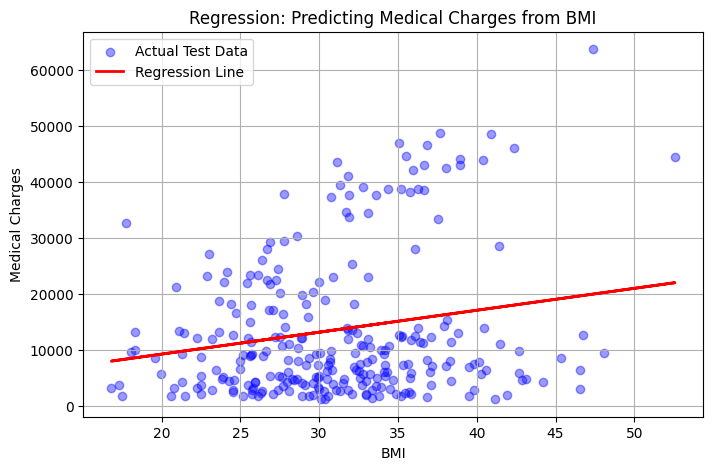

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.4, label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Regression: Predicting Medical Charges from BMI')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.legend()
plt.grid(True)
plt.show()

Example predictions

In [6]:
# Example Prediction
sample_bmi = [[28.5]]
print(f"Predicted medical charge for a BMI of 28.5: ${reg_model.predict(sample_bmi)[0]:.2f}")

Predicted medical charge for a BMI of 28.5: $12537.51


# Unsupervised Learning

The model is given data that is not labeled or classified. The system attempts to learn without a teacher, organizing the data to describe its hidden structure or detect anomalies.

- Input Data: Unlabeled data
- Goal: Find hidden patterns or groupings
- Example: K-Means Clustering, Principal Component Analysis (PCA)

## K Means clustering implementation

Exploring dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load the Palmer Penguins dataset (widely used on Kaggle) via a raw URL
url_penguins = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df_penguins = pd.read_csv(url_penguins)

df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [8]:
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Finding 3 clusters based on flipper length and body mass

In [9]:
X_unsupervised = df_penguins[['flipper_length_mm', 'body_mass_g']].dropna()

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_model.fit(X_unsupervised)

cluster_labels = kmeans_model.predict(X_unsupervised)

Plotting the clusters

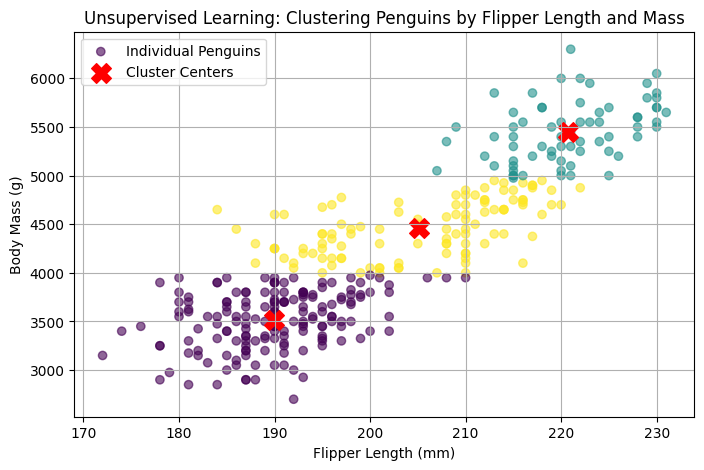

In [10]:
plt.figure(figsize=(8, 5))

# Scatter plot colored by the cluster the model assigned
plt.scatter(X_unsupervised['flipper_length_mm'], X_unsupervised['body_mass_g'], 
            c=cluster_labels, cmap='viridis', alpha=0.6, label='Individual Penguins')

# Plot the center of each cluster 
centroids = kmeans_model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], 
            color='red', marker='X', s=200, label='Cluster Centers')

plt.title('Unsupervised Learning: Clustering Penguins by Flipper Length and Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend()
plt.grid(True)
plt.show()


Assignment a cluster to a point

In [11]:
sample_penguin = [[210.0, 4500.0]] # Flipper length 210mm, Mass 4500g
predicted_cluster = kmeans_model.predict(sample_penguin)[0]
print(f"A penguin with a 210mm flipper and 4500g mass is assigned to Cluster: {predicted_cluster}")

A penguin with a 210mm flipper and 4500g mass is assigned to Cluster: 2
